In [8]:
import pandas as pd, numpy as np
import xgboost as xgb
import mlflow, mlflow.xgboost
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


rfm_clv = pd.read_csv(r'C:\Git projects\customer_lifetime_value\data\data_processed\rfm_clv.csv')

X = rfm_clv[['Recency', 'Frequency', 'Monetary']]
y = rfm_clv['CLV_90d']

# Log-transform target before split
rfm_clv['CLV_90d_log'] = np.log1p(rfm_clv['CLV_90d'])
y = rfm_clv['CLV_90d_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (2883, 3), Test: (721, 3)


In [15]:
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('clv-prediction')


with mlflow.start_run(run_name='xgb-clv-baseline') as run:

    params = {
        'n_estimators':  300,
        'learning_rate': 0.05,
        'max_depth':     5,
        'subsample':     0.8,
        'colsample_bytree': 0.8,
        'random_state':  42
    }
    mlflow.log_params(params)

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    y_pred = model.predict(X_test)

    metrics = {
        'mae':  mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2':   r2_score(y_test, y_pred)
    }
    mlflow.log_metrics(metrics)

    mlflow.xgboost.log_model(
        xgb_model=model,
        artifact_path='model',
        registered_model_name='CLVPredictor',
        input_example=X_test.head(5)
    )

    run_id = run.info.run_id
    print(f'Run ID : {run_id}')
    print(f'MAE    : {np.expm1(metrics["mae"]):.2f}')
    print(f'RMSE   : {np.expm1(metrics["rmse"]):.2f}')
    print(f'R2     : {metrics["r2"]:.4f}')


c:\Git projects\customer_lifetime_value\clv-pgvector-venv\Lib\site-packages\mlflow\types\utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
c:\Git projects\customer_lifetime_value\clv-pgvector-venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [12:03:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8

2026/06/10 12:03:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run xgb-clv-baseline at: http://127.0.0.1:5000/#/experiments/870275771876872824/runs/86f65a877fd4441f8cab56c8db37e5fa.
2026/06/10 12:03:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/870275771876872824.


Run ID : 86f65a877fd4441f8cab56c8db37e5fa
MAE    : 11.21
RMSE   : 17.41
R2     : 0.1800


In [19]:
mae_log  = metrics['mae']   # 2.50 — log scale
mae_pct  = (mae_log / y_test.mean()) * 100

print(f"MAE (log scale):     {mae_log:.2f}")
print(f"Mean target (log):   {y_test.mean():.2f}")
print(f"Error %:             {mae_pct:.1f}%")

# Also in actual pounds
mae_actual = mean_absolute_error(np.expm1(y_test), np.expm1(model.predict(X_test)))
median_actual = np.expm1(y_test).median()
pct_actual = (mae_actual / median_actual) * 100

print(f"\nMAE (£):             £{mae_actual:.2f}")
print(f"Median spend (£):    £{median_actual:.2f}")
print(f"Error % of median:   {pct_actual:.1f}%")

MAE (log scale):     2.50
Mean target (log):   3.27
Error %:             76.5%

MAE (£):             £468.82
Median spend (£):    £114.61
Error % of median:   409.1%


In [20]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(model.predict(X_test))

# Split into zero and non-zero spenders
mask_nonzero = y_test_actual > 0

mae_zero    = mean_absolute_error(y_test_actual[~mask_nonzero], y_pred_actual[~mask_nonzero])
mae_nonzero = mean_absolute_error(y_test_actual[mask_nonzero],  y_pred_actual[mask_nonzero])
median_nonzero = y_test_actual[mask_nonzero].median()

print(f"Zero spenders    — count: {(~mask_nonzero).sum()}, MAE: £{mae_zero:.2f}")
print(f"Non-zero spenders — count: {mask_nonzero.sum()}, MAE: £{mae_nonzero:.2f}")
print(f"Median spend (non-zero): £{median_nonzero:.2f}")
print(f"Error % of non-zero median: {(mae_nonzero/median_nonzero)*100:.1f}%")

Zero spenders    — count: 345, MAE: £47.63
Non-zero spenders — count: 376, MAE: £855.30
Median spend (non-zero): £479.77
Error % of non-zero median: 178.3%


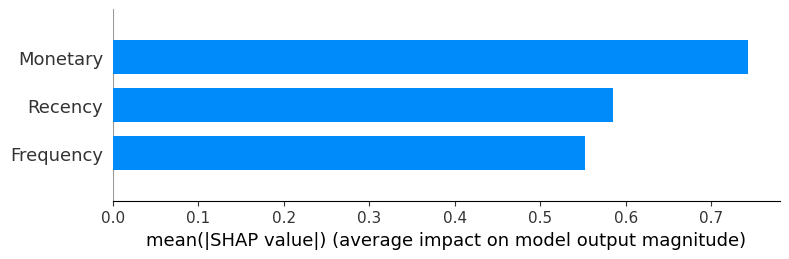

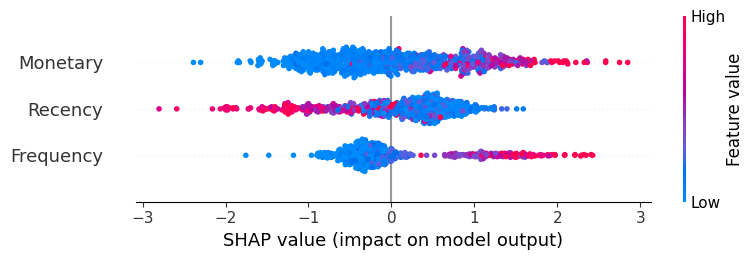

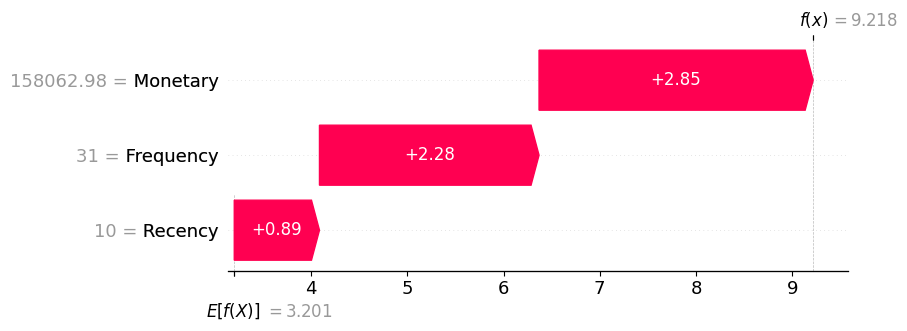

In [12]:
# TreeExplainer works natively with XGBoost — no model wrapping needed
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


# Global feature importance (bar chart)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()


# Beeswarm plot — shows direction of effect per feature
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()


# Single prediction waterfall — explain one high-CLV customer
high_clv_idx = y_test.nlargest(1).index[0]
pos = X_test.index.get_loc(high_clv_idx)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[pos],
        feature_names=X_test.columns.tolist()
    )
)


## CLV Model Interpretation


**MAE (Mean Absolute Error):** On average the model's CLV prediction is
off by £855.30. Given a median 90-day spend of £479.77, this represents 178% error.


**R2:** The model explains ~51% of variance in 90-day spend.
Low R2 is expected — future spend has high inherent randomness.
The goal is directional ranking (who is likely high-value), not
exact spend prediction.


**SHAP findings:**
- Monetary dominates: past spend is the strongest predictor of future spend.
- Recency second: customers who purchased recently are significantly
  more likely to purchase again.
- Frequency contributes but less than the other two — frequency is
  partially captured by Monetary already.


**Business implication:** Target retention and upsell campaigns at
customers with high predicted CLV. Customers with high Monetary
but high Recency (lapsed high-spenders) are the highest-priority
win-back segment.
